In [ ]:
from langgraph.graph import MessagesState
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage, RemoveMessage
from langgraph.graph import StateGraph, START
from langgraph.checkpoint.memory import InMemorySaver
from langchain_google_genai import ChatGoogleGenerativeAI

In [2]:
load_dotenv()

True

In [ ]:
# load_dotenv()
# from langchain_groq import ChatGroq
# # Model
# model = ChatGroq(
#     model="openai/gpt-oss-120b",
#     temperature=0.1)

In [4]:
class ChatState(MessagesState):
    summary: str

In [5]:
def summarize_conversation(state: ChatState):

    existing_summary = state["summary"]

    # Build summarization prompt
    if existing_summary:
        prompt = (
            f"Existing summary:\n{existing_summary}\n\n"
            "Extend the summary using the new conversation above."
        )
    else:
        prompt = "Summarize the conversation above."

    messages_for_summary = state["messages"] + [
        HumanMessage(content=prompt)
    ]

    response = model.invoke(messages_for_summary)

    # Keep only last 2 messages verbatim
    messages_to_delete = state["messages"][:-2]

    return {
        "summary": response.content,
        "messages": [RemoveMessage(id=m.id) for m in messages_to_delete],
    }

In [6]:
def chat_node(state: ChatState):
    messages = []

    if state["summary"]:
        messages.append({
            "role": "system",
            "content": f"Conversation summary:\n{state['summary']}"
        })

    messages.extend(state["messages"])

    print(messages)

    response = model.invoke(messages)
    return {"messages": [response]}

In [7]:
def should_summarize(state: ChatState):
    return len(state["messages"]) > 6

In [8]:
builder = StateGraph(ChatState)

builder.add_node("chat", chat_node)
builder.add_node("summarize", summarize_conversation)

builder.add_edge(START, "chat")

builder.add_conditional_edges(
    "chat",
    should_summarize,
    {
        True: "summarize",
        False: "__end__",
    }
)

builder.add_edge("summarize", "__end__")



In [9]:
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

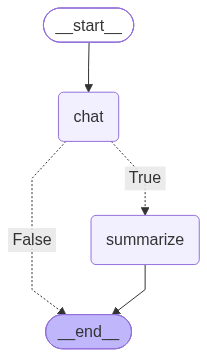

In [10]:
graph

In [11]:
config = {"configurable": {"thread_id": "t1"}}

def run_turn(text: str):
    out = graph.invoke({"messages": [HumanMessage(content=text)], "summary": ""}, config=config)
    return out

In [14]:
# gives the current version of the state
def show_state():
    snap = graph.get_state(config)
    vals = snap.values
    print("\n--- STATE ---")
    print("summary:", vals.get("summary", ""))
    print("num_messages:", len(vals.get("messages", [])))
    print("messages:")
    for m in vals.get("messages", []):
        print("-", type(m).__name__, ":", m.content[:80])

In [13]:
run_turn('Quantum Physics')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='bd7cc21a-d60f-4d9d-b746-d50a25fb991b')]

--- STATE ---
summary: 
num_messages: 2
messages:
- HumanMessage : Quantum Physics
- AIMessage : Sure! Quantum physics (or quantum mechanics) is the branch of physics that descr


In [15]:
run_turn('How is Albert Einstien related?')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='bd7cc21a-d60f-4d9d-b746-d50a25fb991b'), AIMessage(content='Sure! Quantum physics (or quantum mechanics) is the branch of physics that describes how the universe works at the tiniest scales—atoms, electrons, photons, and other elementary particles. At those scales, the rules are very different from the everyday “classical” physics we experience. Below is a quick tour of the most important ideas, followed by a few modern applications and some pointers if you want to dive deeper.\n\n---\n\n## 1. Core Principles\n\n| Principle | What It Says | Everyday Analogy (if any) |\n|-----------|--------------|--------------------------|\n| **Wave‑Particle Duality** | Particles such as electrons and photons behave both like particles **and** like waves. | Light can form interference patterns (a wave property) but also knock electrons out of a metal (a particle property). |\n| **Superposition** | A quantum system 

In [16]:
run_turn('What are some of Einstien"s fampus work')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='bd7cc21a-d60f-4d9d-b746-d50a25fb991b'), AIMessage(content='Sure! Quantum physics (or quantum mechanics) is the branch of physics that describes how the universe works at the tiniest scales—atoms, electrons, photons, and other elementary particles. At those scales, the rules are very different from the everyday “classical” physics we experience. Below is a quick tour of the most important ideas, followed by a few modern applications and some pointers if you want to dive deeper.\n\n---\n\n## 1. Core Principles\n\n| Principle | What It Says | Everyday Analogy (if any) |\n|-----------|--------------|--------------------------|\n| **Wave‑Particle Duality** | Particles such as electrons and photons behave both like particles **and** like waves. | Light can form interference patterns (a wave property) but also knock electrons out of a metal (a particle property). |\n| **Superposition** | A quantum system 


--- STATE ---
summary: 
num_messages: 6
messages:
- HumanMessage : Quantum Physics
- AIMessage : Sure! Quantum physics (or quantum mechanics) is the branch of physics that descr
- HumanMessage : How is Albert Einstien related?
- AIMessage : ### Albert Einstein and Quantum Physics  
Einstein is one of the most famous phy
- HumanMessage : What are some of Einstien"s fampus work
- AIMessage : Below is a quick‑reference guide to **Albert Einstein’s most celebrated scientif


In [17]:
run_turn('Explain special theory of relativity')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='bd7cc21a-d60f-4d9d-b746-d50a25fb991b'), AIMessage(content='Sure! Quantum physics (or quantum mechanics) is the branch of physics that describes how the universe works at the tiniest scales—atoms, electrons, photons, and other elementary particles. At those scales, the rules are very different from the everyday “classical” physics we experience. Below is a quick tour of the most important ideas, followed by a few modern applications and some pointers if you want to dive deeper.\n\n---\n\n## 1. Core Principles\n\n| Principle | What It Says | Everyday Analogy (if any) |\n|-----------|--------------|--------------------------|\n| **Wave‑Particle Duality** | Particles such as electrons and photons behave both like particles **and** like waves. | Light can form interference patterns (a wave property) but also knock electrons out of a metal (a particle property). |\n| **Superposition** | A quantum system 

APIStatusError: Error code: 413 - {'error': {'message': 'Request too large for model `openai/gpt-oss-120b` in organization `org_01ksefjmdpfn7bhpfb313hat9j` service tier `on_demand` on tokens per minute (TPM): Limit 8000, Requested 10281, please reduce your message size and try again. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}